In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the shared src/ folder importable whether this runs from the repo root or notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.uplift_eval import (
    FEATURE_COLUMNS, SPECIAL_COLUMNS, overall_itt, uplift_by_group,
    cumulative_uplift, incremental_in_top, area_above_random,
    random_ranking_null, summarize_null, percent_view,
    plot_uplift_by_group, plot_cumulative,
)

RANDOM_SEED = 2026
EXPECTED_COLUMNS = FEATURE_COLUMNS + SPECIAL_COLUMNS

## Task 4: Load the data

Loaded the three prepared files from `data/`, already split into train/validation/test by our challenge advisor. Used `../data/train.csv.gz` etc since the notebook lives one level down inside `notebooks/`. pandas reads the gzip-compressed files directly, no manual decompression needed.

Checked that the columns match what we expect: the 12 anonymized features (`f0`-`f11`) plus the 4 special columns (`treatment`, `exposure`, `visit`, `conversion`).

**Results:** train has 700,000 rows, validation and test each have 150,000 rows, all with 16 columns. Matches exactly what `data/README.md` said to expect.


In [2]:


train_df = pd.read_csv("../data/train.csv.gz")
val_df = pd.read_csv("../data/validation.csv.gz")
test_df = pd.read_csv("../data/test.csv.gz")

print(train_df.shape, val_df.shape, test_df.shape)
assert set(train_df.columns) == set(EXPECTED_COLUMNS), "columns don't match what the notebook expects"
train_df.head()

(700000, 16) (150000, 16) (150000, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,18.255007,10.059654,8.873602,3.907662,10.280525,4.115453,-7.011752,4.833815,3.895862,13.190056,5.300375,-0.168679,1,0,0,0
1,25.315285,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,22.340863,10.059654,8.214383,4.679882,10.280525,4.115453,-10.006574,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
3,20.831647,10.059654,8.944858,4.679882,11.561050,4.115453,-5.987667,4.833815,3.849228,13.190056,6.349310,-0.168679,1,0,0,0
4,12.616365,10.059654,8.985145,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,13.190056,5.300375,-0.168679,1,0,0,0


## Task 5: Review the data dictionary

Read through `data_dictionary.md` to understand what each column means and how we're allowed to use it. Key things that affect the rest of the project:

- `visit` is the primary outcome we're measuring. `conversion` is only a secondary/optional outcome.
- `exposure` is a diagnostic column only. It tells us whether someone was actually shown the ad after being assigned to treatment, but we can't use it as a model feature or filter our analysis by it.
- `f0` through `f11` are the only columns we use as model inputs. They're anonymized on purpose so we can't map them back to anything identifiable.

Also confirmed our actual data matches what the dictionary describes:

```python
train_df[["treatment", "exposure", "visit", "conversion"]].mean()
```

**Results:** treatment rate about 85%, visit rate about 4.7%, conversion rate about 0.28%, exposure rate about 3%. All consistent with the documentation.

In [3]:
train_df[["treatment", "exposure", "visit", "conversion"]].mean()

treatment     0.849953
exposure      0.030480
visit         0.046939
conversion    0.002839
dtype: float64

## Task 6: Confirm the splits are consistent

Since train/validation/test were already split for us, this task was about verifying that split actually worked, meaning all three files should show similar treatment and outcome rates. If one split had a noticeably different treatment rate, comparisons made across splits later on wouldn't be reliable.

```python
for name, split in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    rates = split[["treatment", "visit", "conversion", "exposure"]].mean()
    print(f"{name}: n={len(split)}  {rates.to_dict()}")
```

**Results:** all three splits came back nearly identical. Treatment rate about 85%, visit rate about 4.7%, conversion rate about 0.28% in every split. Confirms the split is solid and comparisons across train/validation/test can be trusted going forward.

In [4]:
for name, split in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    rates = split[["treatment", "visit", "conversion", "exposure"]].mean()
    print(f"{name}: n={len(split)}  {rates.to_dict()}")

train: n=700000  {'treatment': 0.8499528571428572, 'visit': 0.04693857142857143, 'conversion': 0.0028385714285714286, 'exposure': 0.03048}
validation: n=150000  {'treatment': 0.8499533333333333, 'visit': 0.04694, 'conversion': 0.00284, 'exposure': 0.03106}
test: n=150000  {'treatment': 0.8499533333333333, 'visit': 0.04694, 'conversion': 0.00284, 'exposure': 0.030653333333333335}


## Task 7: Random ranking baseline

A random ranking gives us a reference point. It shows what the uplift results look like when the ranking carries no information, so later models have something concrete to be compared against.

Every record in the **validation** set gets a random score from a seeded generator (seed 2026), so the result is identical on every rerun. No features, outcomes, or `exposure` are used to build the scores. Records are sorted into 10 equal groups of 15,000 (group 1 = highest random score), and within each group we compare the treatment and control visit rates with a 95% confidence interval.

All evaluation code lives in `src/uplift_eval.py` so that every model in the project (random, response model, T-learner, transformed outcome) is scored with exactly the same definitions, as the brief requires. Small differences in the sixth decimal place versus the earlier version of this notebook come from using 1.96 (the brief's formula) instead of `scipy`'s 1.95996.

### 7a. Overall validation effect

The overall intention-to-treat (ITT) effect is the reference every group is compared with.

In [5]:
validation_itt = overall_itt(val_df["treatment"], val_df["visit"])
percent_view(pd.DataFrame([validation_itt]))

,n,n_treatment,n_control,visits_treatment,visits_control,treatment_rate,control_rate,uplift,ci_low,ci_high,incremental_visits,incremental_ci_low,incremental_ci_high
0,150000,127493,22507,6170,871,4.839,3.87,0.97,0.691,1.248,1454.4,1037.1,1871.6


### 7b. Uplift by group

Rates and uplift are shown in percent (uplift in percentage points). Incremental visits = group size × uplift.

In [6]:
rng = np.random.default_rng(RANDOM_SEED)
random_scores = rng.random(len(val_df))

random_table = uplift_by_group(random_scores, val_df["treatment"], val_df["visit"], n_groups=10)
percent_view(random_table)

,group,n,n_treatment,n_control,visits_treatment,visits_control,treatment_rate,control_rate,uplift,ci_low,ci_high,incremental_visits,incremental_ci_low,incremental_ci_high
0,1,15000,12751,2249,611,102,4.792,4.535,0.256,-0.680,1.193,38.5,-102.0,178.9
1,2,15000,12832,2168,594,89,4.629,4.105,0.524,-0.387,1.435,78.6,-58.1,215.2
2,3,15000,12651,2349,642,84,5.075,3.576,1.499,0.656,2.341,224.8,98.4,351.2
3,4,15000,12745,2255,567,81,4.449,3.592,0.857,0.009,1.704,128.5,1.4,255.6
4,5,15000,12777,2223,641,91,5.017,4.094,0.923,0.017,1.830,138.5,2.5,274.5
5,6,15000,12749,2251,601,99,4.714,4.398,0.316,-0.607,1.240,47.4,-91.1,185.9
6,7,15000,12758,2242,614,74,4.813,3.301,1.512,0.684,2.340,226.8,102.7,350.9
7,8,15000,12669,2331,625,71,4.933,3.046,1.887,1.094,2.680,283.1,164.2,402.1
8,9,15000,12770,2230,655,94,5.129,4.215,0.914,-0.004,1.832,137.1,-0.5,274.7
9,10,15000,12791,2209,620,86,4.847,3.893,0.954,0.066,1.842,143.1,9.8,276.4


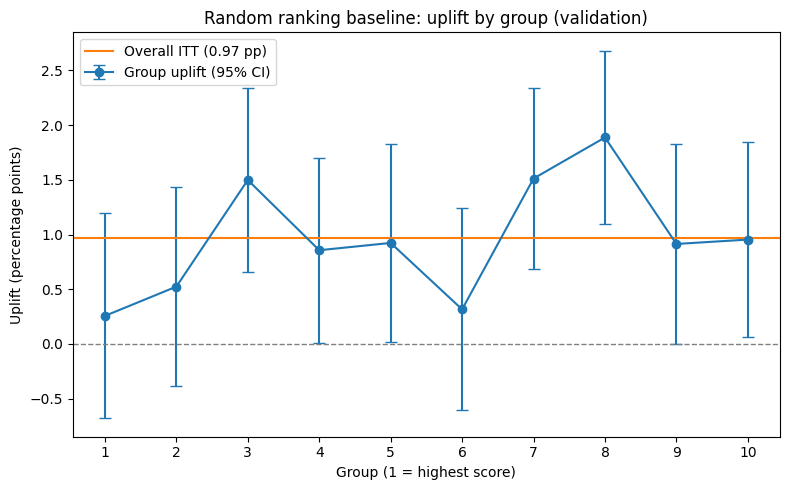

In [7]:
plot_uplift_by_group(
    random_table, itt=validation_itt,
    title="Random ranking baseline: uplift by group (validation)",
)
plt.tight_layout()
plt.show()

**Reading the group results.** Uplift bounces between groups with no trend (0.26, 0.52, 1.50, 0.86, 0.92, 0.32, 1.51, 1.89, 0.91, 0.95 percentage points). Every interval is wide, about ±0.9 points, which is roughly the size of the whole average effect, and the intervals overlap heavily, so no group is statistically different from the others. The groups scatter around the overall ITT line.

The top group happening to have the lowest uplift is luck of this particular seed, not something to expect. A random ranking has no expected pattern: with a different seed, any group could come out highest or lowest (section 7d shows how much).

### 7c. Cumulative incremental visits

This follows the brief's cumulative uplift curve: sort from highest to lowest score, target the top k% of the audience, and estimate the incremental visits captured within that audience (targeted records × uplift inside it). The shaded band is the 95% interval. The dashed line is what a ranking with no information captures on average: the same share of the total incremental visits as the share of the audience targeted.

A useful model should rise above the dashed line early, meaning it captures more than its share of incremental visits in the top-ranked groups.

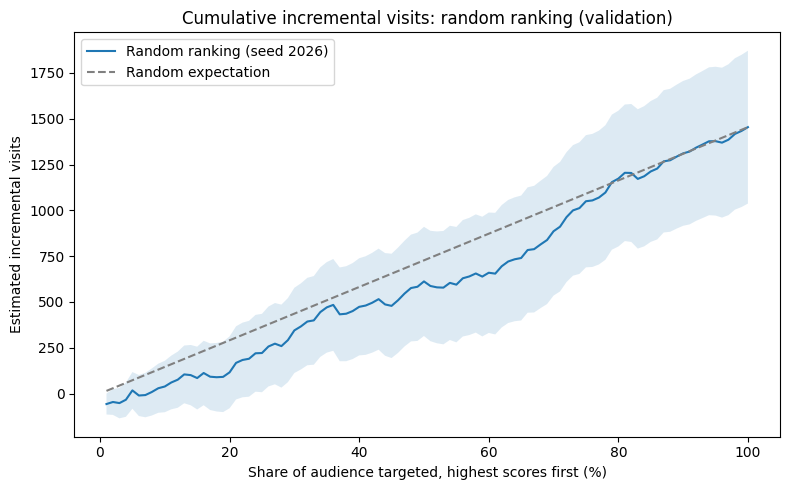

Total incremental visits in validation: 1454
Incremental visits captured in the top 30%: 345 (random expectation: 436)
Area above random line: -0.069


In [8]:
random_curve = cumulative_uplift(random_scores, val_df["treatment"], val_df["visit"])

plot_cumulative(
    {"Random ranking (seed 2026)": random_curve},
    title="Cumulative incremental visits: random ranking (validation)",
)
plt.tight_layout()
plt.show()

top_30 = incremental_in_top(random_curve, 0.3)
print(f"Total incremental visits in validation: {validation_itt['incremental_visits']:.0f}")
print(f"Incremental visits captured in the top 30%: {top_30:.0f} "
      f"(random expectation: {0.3 * validation_itt['incremental_visits']:.0f})")
print(f"Area above random line: {area_above_random(random_curve):.3f}")

### 7d. How much can a random ranking vary by chance?

One seed shows one random draw. Rerunning the random ranking with 200 different seeds shows the range of results a ranking with no information can produce on this validation set. Later models should be compared with this range, not just with zero or with a single random draw.

Only the random scores change between seeds; the validation data stays the same. So this range reflects ranking luck, not the extra uncertainty from having a different sample of customers.

In [9]:
null_results = random_ranking_null(val_df["treatment"], val_df["visit"], n_seeds=200)
null_summary = summarize_null(null_results)
null_summary

,median,p2.5,p97.5
top_group_uplift,0.009582,0.001117,0.018583
best_minus_worst_group,0.013402,0.008075,0.020930
incremental_top_30pct,440.813472,282.211123,630.051444
area_above_random,0.003029,-0.070821,0.081722


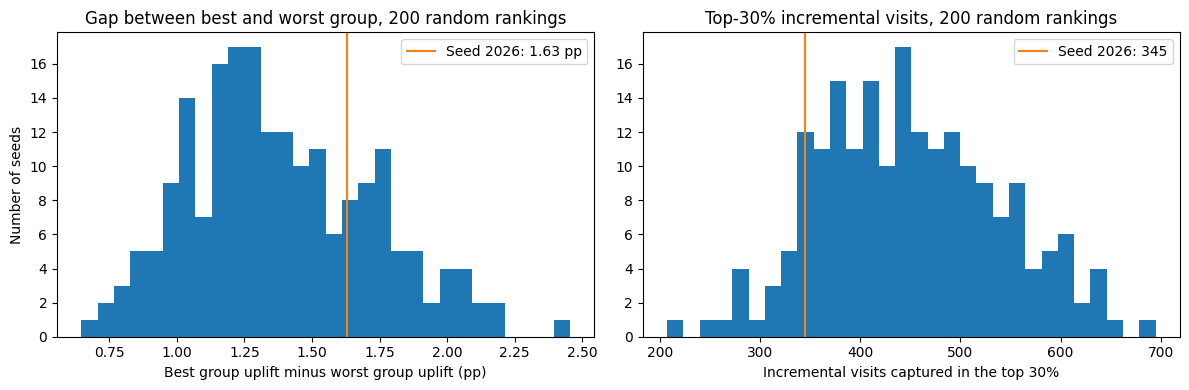

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(null_results["best_minus_worst_group"] * 100, bins=30)
seed_gap = (random_table["uplift"].max() - random_table["uplift"].min()) * 100
axes[0].axvline(seed_gap, color="tab:orange", label=f"Seed 2026: {seed_gap:.2f} pp")
axes[0].set_xlabel("Best group uplift minus worst group uplift (pp)")
axes[0].set_ylabel("Number of seeds")
axes[0].set_title("Gap between best and worst group, 200 random rankings")
axes[0].legend()

axes[1].hist(null_results["incremental_top_30pct"], bins=30)
axes[1].axvline(top_30, color="tab:orange", label=f"Seed 2026: {top_30:.0f}")
axes[1].set_xlabel("Incremental visits captured in the top 30%")
axes[1].set_title("Top-30% incremental visits, 200 random rankings")
axes[1].legend()

plt.tight_layout()
plt.show()

**What this means for the later models.**

- Pure chance produces a gap of roughly 0.8 to 2.1 percentage points between the best and worst group (median about 1.3). That gap is bigger than the entire average effect of about 1 point, so a model's best-versus-worst gap by itself is not evidence that it works.
- Targeting the top 30% by chance captures anywhere from about 280 to 630 incremental visits (median about 440, the expected 30% share of about 1,454). A model is only convincingly better if it lands above this range, and ideally shows the same on the cumulative curve.
- The response model in Task 8 ranks people by how likely they are to visit, not by how much the ad changes their behavior. It may not show a declining uplift pattern at all, and seeing that is the point of building it. The declining-uplift pattern is what the October uplift models (T-learner and transformed outcome) are trying to achieve.
- Every model should be scored with the same functions in `src/uplift_eval.py` and compared against the null range above. When results fall inside that range or intervals overlap heavily, we treat them as ties, as the brief asks.